<a href="https://colab.research.google.com/github/BrisseidaEsmeraldaGonzalezCabriales/InteligenciaArtificial_y_RedesNeuronales_UANL/blob/main/PIA_DMP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando análisis de datos...
✅ Archivo Excel cargado correctamente.

================ TABLA 1 ================
REPOSICIONAMIENTO

                    Giro  Error Promedio (mm)  \
0  Horario / Antihorario                0.131   
1  Antihorario / Horario                0.131   

   Desviación estándar del promedio (mm)  
0                                 0.0733  
1                                 0.0645  

================ TABLA 2 ================
AMPLITUD DE PASO - SENTIDO HORARIO

    Número de Cuenta  Ángulo promedio (mm)  \
0                  0              34.71498   
1                  1              34.79964   
2                  2              34.81956   
3                  3              34.76976   
4                  4              34.79466   
5                  5              34.96896   
6                  6              34.99884   
7                  7              34.92414   
8                  8              34.84944   
9                  9              34.66016   
10    

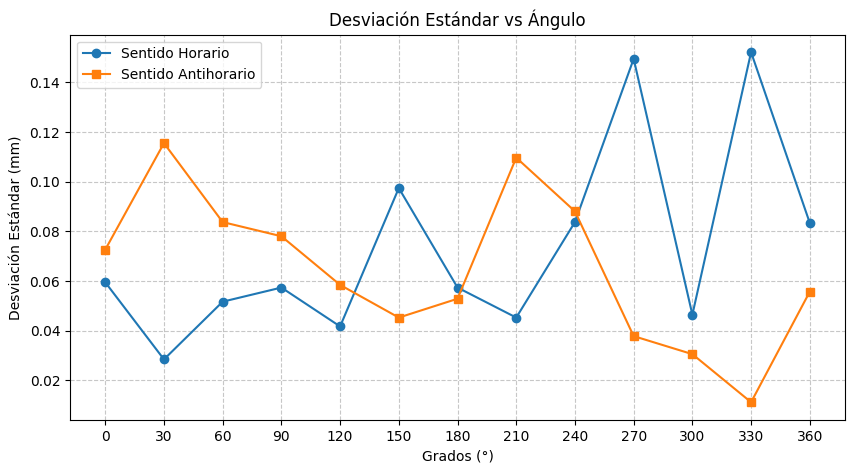


================ TABLA 7 ================
MEDICIÓN PROMEDIO vs ÁNGULO

    Ángulo (°)  Media Horario (mm)  Media Antihorario (mm)
0            0            34.71498                34.68510
1           30            34.79964                34.46092
2           60            34.81956                34.50074
3           90            34.76976                34.71994
4          120            34.79466                34.85940
5          150            34.96896                34.92414
6          180            34.99884                34.98390
7          210            34.92414                34.91516
8          240            34.84944                34.78470
9          270            34.66016                34.72494
10         300            34.47482                34.83450
11         330            34.50078                34.81458
12         360            34.73988                34.71000


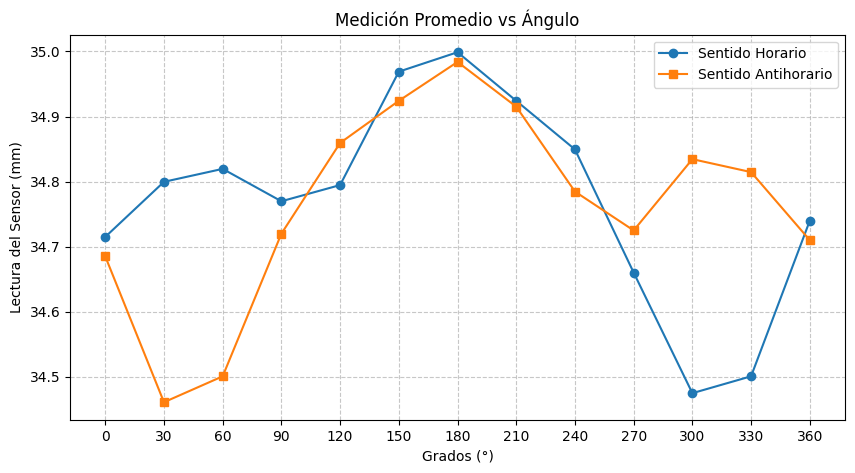


================ TABLA 8 ================
HISTÉRESIS vs ÁNGULO

    Ángulo (°)  Histéresis (mm)
0            0          0.02988
1           30          0.33872
2           60          0.31882
3           90          0.04982
4          120          0.06474
5          150          0.04482
6          180          0.01494
7          210          0.00898
8          240          0.06474
9          270          0.06478
10         300          0.35968
11         330          0.31380
12         360          0.02988


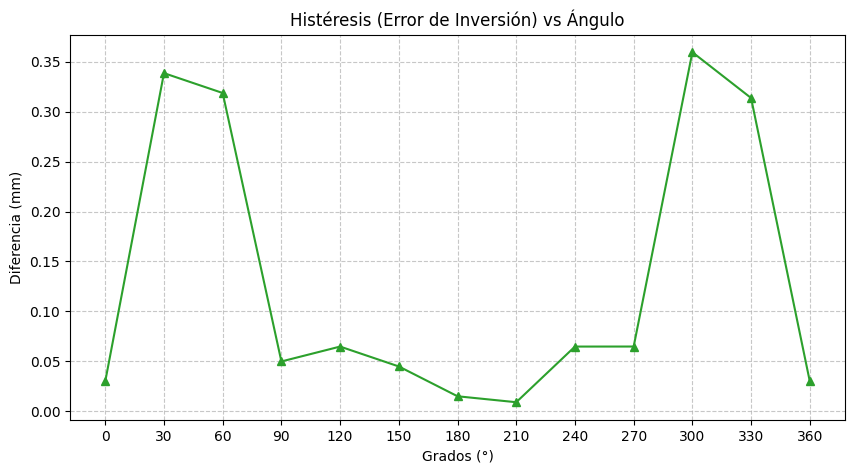


✅ ¡Proceso terminado correctamente!

TABLAS GENERADAS:
Tabla1_Reposicionamiento.csv
Tabla2_Amplitud_Horario.csv
Tabla3_Amplitud_Antihorario.csv
Tabla4_Calibracion_Horario.csv
Tabla5_Calibracion_Antihorario.csv
Tabla6_Desviacion_Estandar.csv
Tabla7_Medicion_Promedio.csv
Tabla8_Histeresis.csv

GRÁFICAS GENERADAS:
Grafica1_Desviacion.png
Grafica2_Medicion_Promedio.png
Grafica3_Histeresis.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Iniciando análisis de datos...")

# =====================================================
# 1. CARGAR ARCHIVO
# =====================================================

archivo_csv = 'MEDICIONES FINAL PIA 2.xlsx - Hoja1.csv'
archivo_xlsx = 'MEDICIONES FINAL PIA 2.xlsx' # Corrected extra space in filename

if os.path.exists(archivo_csv):
    df = pd.read_csv(archivo_csv, header=1)
    print("✅ Archivo CSV cargado correctamente.")

elif os.path.exists(archivo_xlsx):
    df = pd.read_excel(archivo_xlsx, header=1)
    print("✅ Archivo Excel cargado correctamente.")

else:
    print("❌ ERROR: No se encontró el archivo.")
    raise SystemExit

# =====================================================
# 2. LIMPIEZA DE DATOS
# =====================================================

df = df.dropna(how='all', axis=1)

# Correcciones manuales
df.loc[1, '270°mm'] = 34.7100
df.loc[9, '330°mm'] = 34.8096

# =====================================================
# 3. DEFINIR ÁNGULOS
# =====================================================

angles = ['0° REF', '30°mm', '60°mm', '90°mm',
          '120°mm', '150°mm', '180°mm',
          '210°mm', '240°mm', '270°mm',
          '300°mm', '330°mm', '360°mm']

angle_vals = [0, 30, 60, 90,
              120, 150, 180,
              210, 240, 270,
              300, 330, 360]

# =====================================================
# 4. PREPARAR DATOS
# =====================================================

df_data = df.dropna(subset=['SENTIDO']).copy()

for col in angles:
    df_data[col] = pd.to_numeric(df_data[col], errors='coerce')

df_horario = df_data[df_data['SENTIDO'] == 'HORARIO'][angles]
df_anti = df_data[df_data['SENTIDO'] == 'ANTIHORARIO'][angles]

# =====================================================
# 5. CÁLCULOS
# =====================================================

std_horario = df_horario.std(axis=0)
std_anti = df_anti.std(axis=0)

mean_horario = df_horario.mean(axis=0)
mean_anti = df_anti.mean(axis=0)

histeresis = np.abs(mean_horario - mean_anti)

# =====================================================
# TABLA 1 - REPOSICIONAMIENTO
# =====================================================

tabla1 = pd.DataFrame({
    'Giro': ['Horario / Antihorario',
             'Antihorario / Horario'],

    'Error Promedio (mm)': [
        round(histeresis.mean(), 4),
        round(histeresis.mean(), 4)
    ],

    'Desviación estándar del promedio (mm)': [
        round(std_horario.mean(), 4),
        round(std_anti.mean(), 4)
    ]
})

tabla1.to_csv('Tabla1_Reposicionamiento.csv', index=False)

print("\n================ TABLA 1 ================")
print("REPOSICIONAMIENTO\n")
print(tabla1)

# =====================================================
# TABLA 2 - AMPLITUD DE PASO SENTIDO HORARIO
# =====================================================

tabla2 = pd.DataFrame({
    'Número de Cuenta': range(len(angle_vals)),

    'Ángulo promedio (mm)': mean_horario.values,

    'Desviación estándar del ángulo promedio (mm)': std_horario.values
})

tabla2.to_csv('Tabla2_Amplitud_Horario.csv', index=False)

print("\n================ TABLA 2 ================")
print("AMPLITUD DE PASO - SENTIDO HORARIO\n")
print(tabla2)

# =====================================================
# TABLA 3 - AMPLITUD DE PASO SENTIDO ANTIHORARIO
# =====================================================

tabla3 = pd.DataFrame({
    'Número de Cuenta': range(len(angle_vals)),

    'Ángulo promedio (mm)': mean_anti.values,

    'Desviación estándar (mm)': std_anti.values
})

tabla3.to_csv('Tabla3_Amplitud_Antihorario.csv', index=False)

print("\n================ TABLA 3 ================")
print("AMPLITUD DE PASO - SENTIDO ANTIHORARIO\n")
print(tabla3)

# =====================================================
# TABLA 4 - CALIBRACIÓN MESA ROTATORIA
# SENTIDO HORARIO
# =====================================================

tabla4 = pd.DataFrame({
    'Valor nominal (°)': angle_vals,

    'Error promedio (mm)': mean_horario.values,

    'Desviación estándar del error promedio (mm)': std_horario.values
})

tabla4.to_csv('Tabla4_Calibracion_Horario.csv', index=False)

print("\n================ TABLA 4 ================")
print("CALIBRACIÓN DE LA MESA ROTATORIA - SENTIDO HORARIO\n")
print(tabla4)

# =====================================================
# TABLA 5 - CALIBRACIÓN MESA ROTATORIA
# SENTIDO ANTIHORARIO
# =====================================================

tabla5 = pd.DataFrame({
    'Valor nominal (°)': angle_vals,

    'Error promedio (mm)': mean_anti.values,

    'Desviación estándar del error promedio (mm)': std_anti.values
})

tabla5.to_csv('Tabla5_Calibracion_Antihorario.csv', index=False)

print("\n================ TABLA 5 ================")
print("CALIBRACIÓN DE LA MESA ROTATORIA - SENTIDO ANTIHORARIO\n")
print(tabla5)

# =====================================================
# TABLA 6 - DESVIACIÓN ESTÁNDAR vs ÁNGULO
# =====================================================

tabla6 = pd.DataFrame({
    'Ángulo (°)': angle_vals,

    'Desviación Horario (mm)': std_horario.values,

    'Desviación Antihorario (mm)': std_anti.values
})

tabla6.to_csv('Tabla6_Desviacion_Estandar.csv', index=False)

print("\n================ TABLA 6 ================")
print("DESVIACIÓN ESTÁNDAR vs ÁNGULO\n")
print(tabla6)

# =====================================================
# GRÁFICA 1
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(angle_vals,
         std_horario,
         marker='o',
         label='Sentido Horario')

plt.plot(angle_vals,
         std_anti,
         marker='s',
         label='Sentido Antihorario')

plt.title('Desviación Estándar vs Ángulo')
plt.xlabel('Grados (°)')
plt.ylabel('Desviación Estándar (mm)')

plt.xticks(angle_vals)
plt.legend()

plt.grid(True,
         linestyle='--',
         alpha=0.7)

plt.savefig('Grafica1_Desviacion.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

# =====================================================
# TABLA 7 - MEDICIÓN PROMEDIO vs ÁNGULO
# =====================================================

tabla7 = pd.DataFrame({
    'Ángulo (°)': angle_vals,

    'Media Horario (mm)': mean_horario.values,

    'Media Antihorario (mm)': mean_anti.values
})

tabla7.to_csv('Tabla7_Medicion_Promedio.csv', index=False)

print("\n================ TABLA 7 ================")
print("MEDICIÓN PROMEDIO vs ÁNGULO\n")
print(tabla7)

# =====================================================
# GRÁFICA 2
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(angle_vals,
         mean_horario,
         marker='o',
         label='Sentido Horario')

plt.plot(angle_vals,
         mean_anti,
         marker='s',
         label='Sentido Antihorario')

plt.title('Medición Promedio vs Ángulo')
plt.xlabel('Grados (°)')
plt.ylabel('Lectura del Sensor (mm)')

plt.xticks(angle_vals)
plt.legend()

plt.grid(True,
         linestyle='--',
         alpha=0.7)

plt.savefig('Grafica2_Medicion_Promedio.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

# =====================================================
# TABLA 8 - HISTÉRESIS vs ÁNGULO
# =====================================================

tabla8 = pd.DataFrame({
    'Ángulo (°)': angle_vals,

    'Histéresis (mm)': histeresis.values
})

tabla8.to_csv('Tabla8_Histeresis.csv', index=False)

print("\n================ TABLA 8 ================")
print("HISTÉRESIS vs ÁNGULO\n")
print(tabla8)

# =====================================================
# GRÁFICA 3
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(angle_vals,
         histeresis,
         marker='^',
         color='#2ca02c')

plt.title('Histéresis (Error de Inversión) vs Ángulo')
plt.xlabel('Grados (°)')
plt.ylabel('Diferencia (mm)')

plt.xticks(angle_vals)

plt.grid(True,
         linestyle='--',
         alpha=0.7)

plt.savefig('Grafica3_Histeresis.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

# =====================================================
# MENSAJE FINAL
# =====================================================

print("\n✅ ¡Proceso terminado correctamente!")

print("\nTABLAS GENERADAS:")
print("Tabla1_Reposicionamiento.csv")
print("Tabla2_Amplitud_Horario.csv")
print("Tabla3_Amplitud_Antihorario.csv")
print("Tabla4_Calibracion_Horario.csv")
print("Tabla5_Calibracion_Antihorario.csv")
print("Tabla6_Desviacion_Estandar.csv")
print("Tabla7_Medicion_Promedio.csv")
print("Tabla8_Histeresis.csv")

print("\nGRÁFICAS GENERADAS:")
print("Grafica1_Desviacion.png")
print("Grafica2_Medicion_Promedio.png")
print("Grafica3_Histeresis.png")